# 51 Regresión Lineal — Comparativa OLS Base vs Ridge vs Lasso+OLS

Unificación de los tres notebooks de regresión lineal para `sale` y `rent` prediciendo `log_precio`.

| Modelo | Features | Regularización | Inferencia |
|--------|----------|---------------|------------|
| **OLS Base** | 11 features parsimoniosas | Ninguna | statsmodels (coef, p-value, IC95) |
| **Ridge** | Conjunto completo + municipios | L2 (RidgeCV) | coef estandarizados |
| **Lasso+OLS** | Conjunto completo + municipios → selección Lasso | L1 (LassoCV) + OLS | statsmodels (coef, p-value, IC95) |

**Pipeline común:**
1. Eliminación de outliers en `log_precio` con método IQR antes del split
2. Split 80/20 train/test (`random_state=42`)
3. Validación cruzada 5-fold (CV=5): MSE, RMSE, MAE, MAPE y R²
4. Gráficos diagnósticos: Real vs Predicho, residuos, histograma residuos
5. **Resumen comparativo global** al final

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression, LassoCV, Ridge, RidgeCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

In [10]:
# ── Configuración global ──────────────────────────────────────────────────────
RANDOM_STATE            = 42
TEST_SIZE               = 0.20
N_SPLITS                = 5
TARGET_COL              = "log_precio"
# Alphas candidatos para RidgeCV
RIDGE_ALPHAS = np.logspace(-3, 5, 200)

# ── Features OLS Base (parsimonioso — 11 regresores) ─────────────────────────
BASE_FEATURES = [
    "log_superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "distancia_centro_municipio_km",
    "tipologia_unificada_unifamiliar",
    "precio_m2_municipio_media",
]

# ── Features candidatas Ridge (21 regresores) ────────────────────────────────
# es_exterior / tiene_ascensor → renombradas a *_piso en build_candidate_X
CANDIDATE_FEATURES_RIDGE = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "latitud",
    "longitud",
    "planta_num",
    "es_exterior_piso",
    "tiene_ascensor_piso",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "precio_m2_municipio_media",
    "ratio_dormitorios_superficie",
    "ratio_banos_superficie",
    "interaccion_planta_sin_ascensor_piso",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    # municipio_* se añaden dinámicamente
]

# ── Features candidatas Lasso (27 regresores) ────────────────────────────────
# es_exterior / tiene_ascensor → renombradas a *_piso en build_candidate_X
CANDIDATE_FEATURES_LASSO = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "latitud",
    "longitud",
    "planta_num",
    "es_exterior_piso",
    "tiene_ascensor_piso",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "precio_m2_municipio_media",
    "ratio_banos_superficie",
    "interaccion_superficie_banos",
    "interaccion_planta_sin_ascensor_piso",
    "latitud_2",
    "longitud_2",
    "interaccion_latitud_longitud",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "superficie_construida_m2_2",
    "numero_banos_2",
    "numero_dormitorios_2",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    # municipio_* se añaden dinámicamente
]

# ── Rutas de datos ────────────────────────────────────────────────────────────
def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data" / "gold").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto con data/gold")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale_idealistaAPI.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent_idealistaAPI.csv",
}

for name, path in DATASETS.items():
    if not path.exists():
        raise FileNotFoundError(f"No se encontro {name}: {path}")

print("Datasets listos:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")

Datasets listos:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale_idealistaAPI.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent_idealistaAPI.csv


In [11]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────



def compute_metrics(y_true, y_pred, n_features: int) -> dict:
    mse    = mean_squared_error(y_true, y_pred)
    r2     = r2_score(y_true, y_pred)
    n      = len(y_true)
    r2_adj = (
        1 - (1 - r2) * (n - 1) / (n - n_features - 1)
        if n > n_features + 1 else np.nan
    )
    return {
        "MSE":         float(mse),
        "RMSE":        float(np.sqrt(mse)),
        "MAE":         float(mean_absolute_error(y_true, y_pred)),
        "MAPE":        float(mean_absolute_percentage_error(y_true, y_pred)),
        "R2":          float(r2),
        "R2_ajustado": float(r2_adj),
    }


def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    """VIF para cada regresor. VIF > 5 → moderada; VIF > 10 → severa."""
    Xc  = sm.add_constant(X.astype(float))
    vif = pd.DataFrame({
        "feature": Xc.columns,
        "VIF":     [variance_inflation_factor(Xc.values.astype(float), i)
                    for i in range(Xc.shape[1])],
    })
    return (
        vif[vif["feature"] != "const"]
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )


def cv_ols_metrics(X: pd.DataFrame, y: pd.Series, n_features: int) -> dict:
    """Validacion cruzada 5-fold con LinearRegression (equiv. OLS)."""
    kf           = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_results = []
    for tr_idx, val_idx in kf.split(X):
        mdl = LinearRegression()
        mdl.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = mdl.predict(X.iloc[val_idx])
        fold_results.append(compute_metrics(y.iloc[val_idx], pred, n_features))
    return {k: float(np.mean([m[k] for m in fold_results])) for k in fold_results[0]}


def cv_ridge_metrics(X: pd.DataFrame, y: pd.Series, alpha: float, n_features: int) -> dict:
    """Validacion cruzada 5-fold con Ridge (estandarizado dentro de cada fold)."""
    kf           = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_results = []
    for tr_idx, val_idx in kf.split(X):
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge",  Ridge(alpha=alpha)),
        ])
        pipe.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = pipe.predict(X.iloc[val_idx])
        fold_results.append(compute_metrics(y.iloc[val_idx], pred, n_features))
    return {k: float(np.mean([m[k] for m in fold_results])) for k in fold_results[0]}


def fit_ols_statsmodels(X_train: pd.DataFrame, y_train: pd.Series):
    """Ajusta OLS con statsmodels (incluye constante)."""
    Xc = sm.add_constant(X_train.astype(float))
    return sm.OLS(y_train, Xc).fit()


def print_coef_summary(result) -> None:
    """Tabla de coeficientes OLS ordenada por magnitud absoluta."""
    coef_df = pd.DataFrame({
        "coef":      result.params,
        "std_err":   result.bse,
        "t":         result.tvalues,
        "p_value":   result.pvalues,
        "IC_95_inf": result.conf_int()[0],
        "IC_95_sup": result.conf_int()[1],
    })
    coef_df = coef_df.drop(index="const", errors="ignore")
    coef_df["|coef|"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("|coef|", ascending=False).drop(columns="|coef|")
    print(coef_df.round(5).to_string())


def group_small_municipios(df: pd.DataFrame) -> tuple:
    """Devuelve el df sin cambios y las columnas municipio_* disponibles.
    El colapso de municipios con pocas obs ya se realizó en el gold notebook."""
    final_mun_cols = sorted([c for c in df.columns if c.startswith("municipio_")])
    return df, final_mun_cols


def build_base_X(df: pd.DataFrame) -> pd.DataFrame:
    """Matriz de features parsimoniosa para OLS base."""
    features = [f for f in BASE_FEATURES if f in df.columns]
    X = df[features].copy()
    return X.fillna(X.median(numeric_only=True))


def build_candidate_X(df: pd.DataFrame, candidate_features: list) -> pd.DataFrame:
    """Matriz de features para Ridge o Lasso (con municipios).

    es_exterior_piso y tiene_ascensor_piso ya vienen pre-calculadas en el gold
    (= valor_raw x is_piso), por lo que se usan directamente sin renombrado.
    """
    df2, mun_cols = group_small_municipios(df)
    base_feats = []
    for f in candidate_features:
        if f in df2.columns and f not in base_feats:
            base_feats.append(f)
    all_feats = base_feats + [m for m in mun_cols if m not in base_feats]
    all_feats = [f for f in all_feats if f in df2.columns]
    X = df2[all_feats].copy()
    return X.fillna(X.median(numeric_only=True))


def select_features_lasso(X_train: pd.DataFrame, y_train: pd.Series) -> tuple:
    """Usa LassoCV (estandarizado, CV=5) para seleccionar features con coef != 0."""
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    lasso_cv = LassoCV(
        cv=N_SPLITS, random_state=RANDOM_STATE, max_iter=10_000, n_alphas=200
    )
    lasso_cv.fit(X_scaled, y_train)
    alpha_opt = lasso_cv.alpha_
    coefs     = pd.Series(lasso_cv.coef_, index=X_train.columns)
    selected  = coefs[coefs != 0].index.tolist()
    return selected, alpha_opt, coefs


def plot_diagnostics(y_test, pred_test, title: str) -> None:
    """Graficos diagnosticos: Real vs Predicho, Residuos, Histograma."""
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=20, color="steelblue")
    lim = [
        min(y_test.min(), pred_test.min()) - 0.05,
        max(y_test.max(), pred_test.max()) + 0.05,
    ]
    ax.plot(lim, lim, "r--", linewidth=1.5, label="Prediccion perfecta")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")
    ax.set_title("Real vs Predicho — test")
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.scatter(pred_test, residuals, alpha=0.5, s=20, color="darkorange")
    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Predicho (log_precio)")
    ax.set_ylabel("Residuo (real - predicho)")
    ax.set_title("Residuos vs Predicho — test")

    ax = axes[2]
    ax.hist(residuals, bins=30, color="steelblue", alpha=0.75, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Residuo")
    ax.set_ylabel("Frecuencia")
    ax.set_title("Distribucion residuos — test")

    plt.tight_layout()
    plt.show()


print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


## Ejecucion principal — los tres modelos por dataset


DATASET: SALE
Filas cargadas: 2700

──────────────────────────────────────────────────────────────────────
MODELO 1: OLS BASE (11 features parsimoniosas, sin regularizacion)
──────────────────────────────────────────────────────────────────────

Features (11): ['log_superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'distancia_centro_municipio_km', 'tipologia_unificada_unifamiliar', 'precio_m2_municipio_media']
Train: 2160 | Test: 540

── Metricas ────────────────────────────────────────────────────────
      split     MSE    RMSE     MAE    MAPE      R2  R2_ajustado
      train 0.12570 0.35454 0.27078 0.02172 0.63677      0.63491
CV (5-fold) 0.13144 0.36217 0.27679 0.02221 0.62336      0.61551
       test 0.14855 0.38542 0.29353 0.02361 0.58799      0.57941

  delta RMSE test-train : +0.03088
  delta R2   train-test : +0.04878
  R2 ajustado (statsmodels):

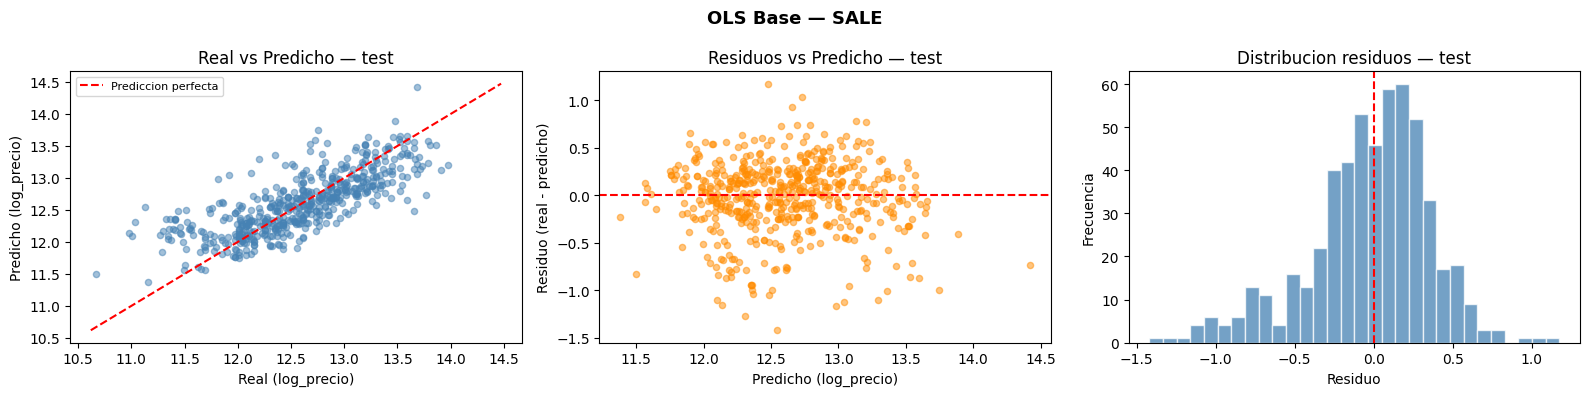


──────────────────────────────────────────────────────────────────────
MODELO 2: Ridge con RidgeCV (features Ridge + municipios)
──────────────────────────────────────────────────────────────────────

── Ingenieria de features ──────────────────────────────────────────

Features candidatas (52): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'latitud', 'longitud', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Guarni

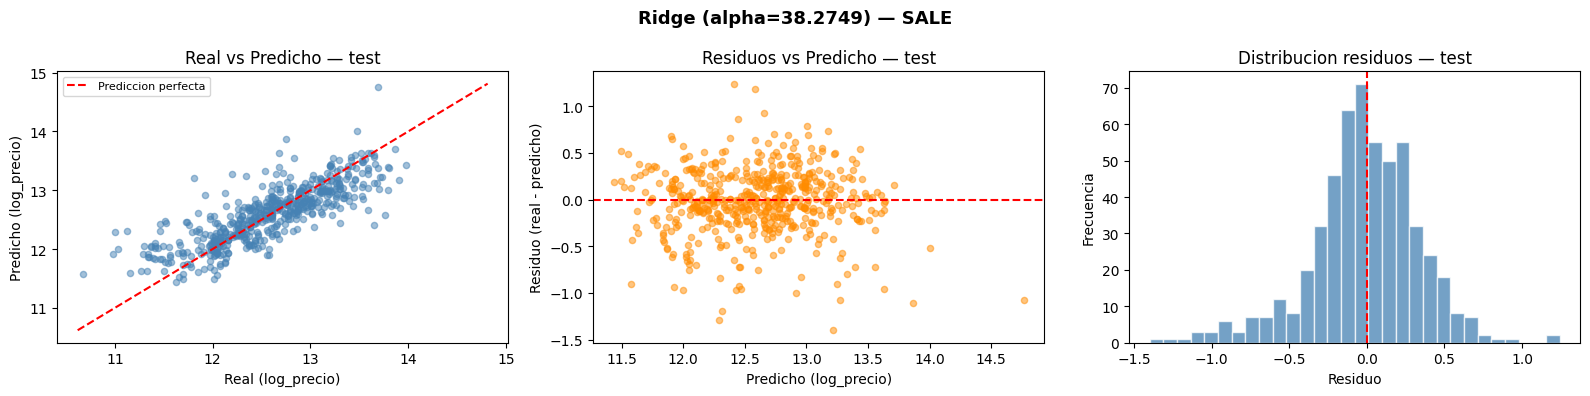


──────────────────────────────────────────────────────────────────────
MODELO 3: OLS + seleccion de variables con LassoCV
──────────────────────────────────────────────────────────────────────

── Ingenieria de features ──────────────────────────────────────────

Features candidatas (58): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'latitud', 'longitud', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_banos_superficie', 'interaccion_superficie_banos', 'interaccion_planta_sin_ascensor_piso', 'latitud_2', 'longitud_2', 'interaccion_latitud_longitud', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'superficie_construida_m2_2', 'numero_banos_2', 'numero_dormitorios_2', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_

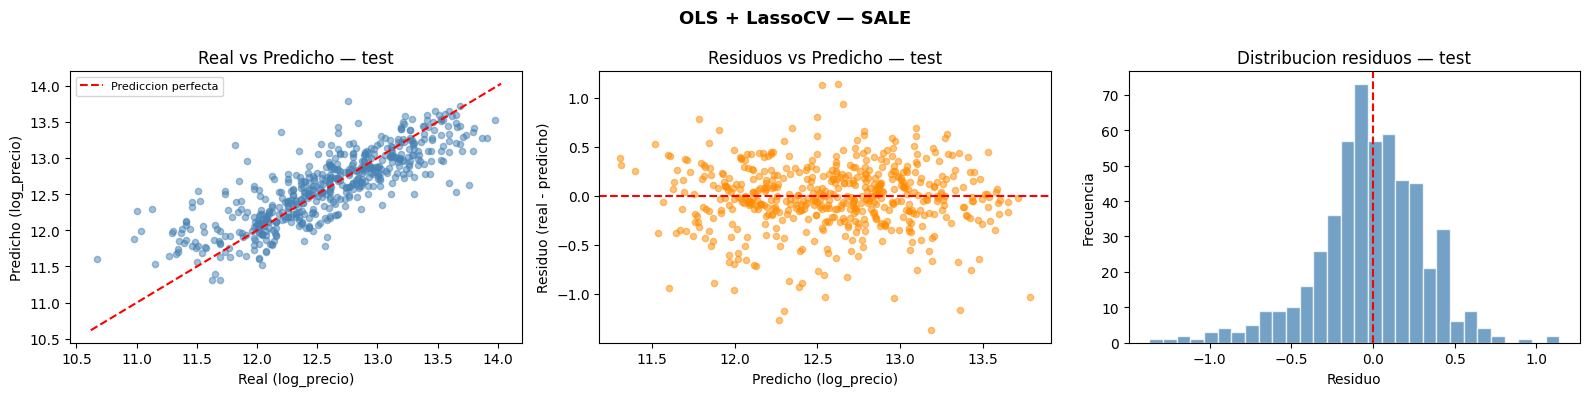


DATASET: RENT
Filas cargadas: 776

──────────────────────────────────────────────────────────────────────
MODELO 1: OLS BASE (11 features parsimoniosas, sin regularizacion)
──────────────────────────────────────────────────────────────────────

Features (11): ['log_superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'distancia_centro_municipio_km', 'tipologia_unificada_unifamiliar', 'precio_m2_municipio_media']
Train: 620 | Test: 156

── Metricas ────────────────────────────────────────────────────────
      split     MSE    RMSE     MAE    MAPE      R2  R2_ajustado
      train 0.04871 0.22071 0.16311 0.02333 0.53468      0.52626
CV (5-fold) 0.05093 0.22547 0.16513 0.02368 0.51356      0.47619
       test 0.05103 0.22589 0.16674 0.02427 0.52985      0.49394

  delta RMSE test-train : +0.00518
  delta R2   train-test : +0.00483
  R2 ajustado (statsmodels): 0

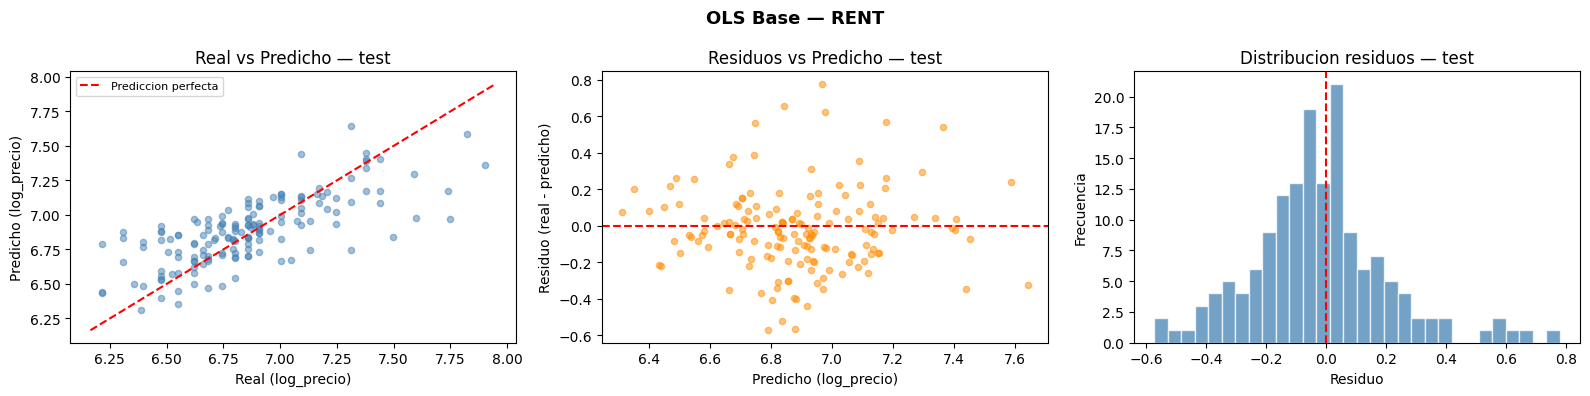


──────────────────────────────────────────────────────────────────────
MODELO 2: Ridge con RidgeCV (features Ridge + municipios)
──────────────────────────────────────────────────────────────────────

── Ingenieria de features ──────────────────────────────────────────

Features candidatas (31): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'latitud', 'longitud', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_El Astillero', 'municipio_Laredo', 'municipio_Piélagos', 'municipio_Santa Cruz de Bezana', 'municipio_Santander', 'municipio_S

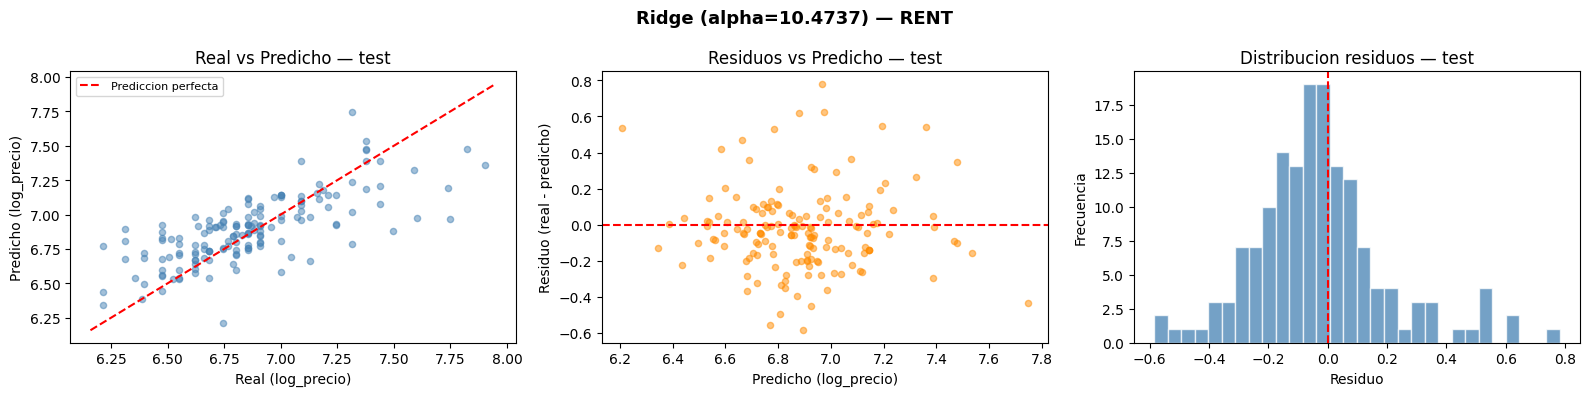


──────────────────────────────────────────────────────────────────────
MODELO 3: OLS + seleccion de variables con LassoCV
──────────────────────────────────────────────────────────────────────

── Ingenieria de features ──────────────────────────────────────────

Features candidatas (37): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'latitud', 'longitud', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_banos_superficie', 'interaccion_superficie_banos', 'interaccion_planta_sin_ascensor_piso', 'latitud_2', 'longitud_2', 'interaccion_latitud_longitud', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'superficie_construida_m2_2', 'numero_banos_2', 'numero_dormitorios_2', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_El

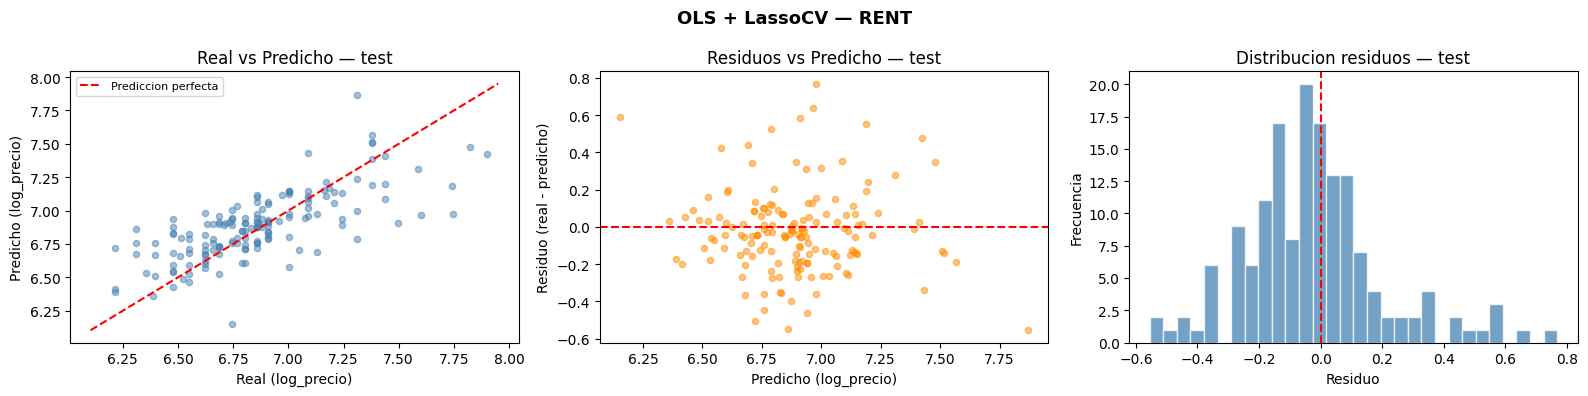

In [12]:
all_results = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 100)

    # ── Carga ─────────────────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"Filas cargadas: {len(df)}")

    y = df[TARGET_COL].copy()

    # ═══════════════════════════════════════════════════════════════════════════
    # MODELO 1 — OLS BASE (parsimonioso, 11 features)
    # ═══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 70)
    print("MODELO 1: OLS BASE (11 features parsimoniosas, sin regularizacion)")
    print("─" * 70)

    X_base = build_base_X(df)
    n_feat_b = X_base.shape[1]
    print(f"\nFeatures ({n_feat_b}): {X_base.columns.tolist()}")

    X_train_b, X_test_b, y_train, y_test = train_test_split(
        X_base, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train_b)} | Test: {len(X_test_b)}")

    ols_base     = fit_ols_statsmodels(X_train_b, y_train)
    X_train_bc   = sm.add_constant(X_train_b.astype(float))
    X_test_bc    = sm.add_constant(X_test_b.astype(float), has_constant="add")
    pred_train_b = ols_base.predict(X_train_bc)
    pred_test_b  = ols_base.predict(X_test_bc)

    train_m_b = compute_metrics(y_train, pred_train_b, n_feat_b)
    test_m_b  = compute_metrics(y_test,  pred_test_b,  n_feat_b)
    cv_m_b    = cv_ols_metrics(X_base, y, n_feat_b)

    print("\n── Metricas ────────────────────────────────────────────────────────")
    print(pd.DataFrame([
        {"split": "train",                **train_m_b},
        {"split": f"CV ({N_SPLITS}-fold)", **cv_m_b},
        {"split": "test",                 **test_m_b},
    ]).round(5).to_string(index=False))
    print(f"\n  delta RMSE test-train : {test_m_b['RMSE'] - train_m_b['RMSE']:+.5f}")
    print(f"  delta R2   train-test : {train_m_b['R2'] - test_m_b['R2']:+.5f}")
    print(f"  R2 ajustado (statsmodels): {ols_base.rsquared_adj:.5f}")
    print(f"  F-stat: {ols_base.fvalue:.2f}  p-value F: {ols_base.f_pvalue:.2e}")

    print("\n── Coeficientes OLS (ordenados por |coef|) ─────────────────────────")
    print_coef_summary(ols_base)

    plot_diagnostics(y_test, pred_test_b, f"OLS Base — {dataset_name.upper()}")

    all_results.append({
        "dataset":  dataset_name,
        "modelo":   "OLS_base",
        "n_features": n_feat_b,
        "alpha":    "—",
        "train_RMSE":      train_m_b["RMSE"],
        "train_R2":        train_m_b["R2"],
        "train_R2_adj":    train_m_b["R2_ajustado"],
        f"CV_{N_SPLITS}f_RMSE": cv_m_b["RMSE"],
        f"CV_{N_SPLITS}f_R2":   cv_m_b["R2"],
        "test_RMSE":  test_m_b["RMSE"],
        "test_R2":    test_m_b["R2"],
        "test_MAE":   test_m_b["MAE"],
        "test_MAPE":  test_m_b["MAPE"],
        "delta_RMSE": test_m_b["RMSE"] - train_m_b["RMSE"],
        "delta_R2":   train_m_b["R2"]  - test_m_b["R2"],
    })

    # ═══════════════════════════════════════════════════════════════════════════
    # MODELO 2 — RIDGE (RidgeCV, features Ridge)
    # ═══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 70)
    print("MODELO 2: Ridge con RidgeCV (features Ridge + municipios)")
    print("─" * 70)

    print("\n── Ingenieria de features ──────────────────────────────────────────")
    X_cand   = build_candidate_X(df, CANDIDATE_FEATURES_RIDGE)
    n_feat_r = X_cand.shape[1]
    print(f"\nFeatures candidatas ({n_feat_r}): {X_cand.columns.tolist()}")

    X_train_r, X_test_r, y_train, y_test = train_test_split(
        X_cand, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train_r)} | Test: {len(X_test_r)}")

    scaler_r   = StandardScaler()
    X_train_rs = scaler_r.fit_transform(X_train_r)
    X_test_rs  = scaler_r.transform(X_test_r)

    print("\n── RidgeCV (seleccion de alpha) ────────────────────────────────────")
    ridge_cv = RidgeCV(
        alphas=RIDGE_ALPHAS, cv=N_SPLITS, scoring="neg_mean_squared_error"
    )
    ridge_cv.fit(X_train_rs, y_train)
    alpha_ridge = ridge_cv.alpha_
    print(f"  Alpha optimo (CV): {alpha_ridge:.6f}")
    print(f"  Rango explorado: [{RIDGE_ALPHAS.min():.1e}, {RIDGE_ALPHAS.max():.1e}] ({len(RIDGE_ALPHAS)} valores)")

    ridge = Ridge(alpha=alpha_ridge)
    ridge.fit(X_train_rs, y_train)
    pred_train_r = ridge.predict(X_train_rs)
    pred_test_r  = ridge.predict(X_test_rs)

    train_m_r = compute_metrics(y_train, pred_train_r, n_feat_r)
    test_m_r  = compute_metrics(y_test,  pred_test_r,  n_feat_r)
    cv_m_r    = cv_ridge_metrics(X_cand, y, alpha_ridge, n_feat_r)

    print("\n── Metricas ────────────────────────────────────────────────────────")
    print(pd.DataFrame([
        {"split": "train",                **train_m_r},
        {"split": f"CV ({N_SPLITS}-fold)", **cv_m_r},
        {"split": "test",                 **test_m_r},
    ]).round(5).to_string(index=False))
    print(f"\n  delta RMSE test-train : {test_m_r['RMSE'] - train_m_r['RMSE']:+.5f}")
    print(f"  delta R2   train-test : {train_m_r['R2'] - test_m_r['R2']:+.5f}")

    print("\n── Coeficientes Ridge estandarizados (ordenados por |coef_std|) ────")
    coef_df_r = pd.DataFrame({
        "feature":   X_train_r.columns,
        "coef_std":  ridge.coef_,
        "coef_orig": ridge.coef_ / scaler_r.scale_,
    })
    coef_df_r["|coef_std|"] = coef_df_r["coef_std"].abs()
    coef_df_r = coef_df_r.sort_values("|coef_std|", ascending=False).drop(columns="|coef_std|")
    print(coef_df_r.round(5).to_string(index=False))
    print(f"\n  Intercepto (escala estandarizada): {ridge.intercept_:.5f}")

    plot_diagnostics(y_test, pred_test_r, f"Ridge (alpha={alpha_ridge:.4f}) — {dataset_name.upper()}")

    all_results.append({
        "dataset":  dataset_name,
        "modelo":   "Ridge",
        "n_features": n_feat_r,
        "alpha":    round(alpha_ridge, 6),
        "train_RMSE":      train_m_r["RMSE"],
        "train_R2":        train_m_r["R2"],
        "train_R2_adj":    train_m_r["R2_ajustado"],
        f"CV_{N_SPLITS}f_RMSE": cv_m_r["RMSE"],
        f"CV_{N_SPLITS}f_R2":   cv_m_r["R2"],
        "test_RMSE":  test_m_r["RMSE"],
        "test_R2":    test_m_r["R2"],
        "test_MAE":   test_m_r["MAE"],
        "test_MAPE":  test_m_r["MAPE"],
        "delta_RMSE": test_m_r["RMSE"] - train_m_r["RMSE"],
        "delta_R2":   train_m_r["R2"]  - test_m_r["R2"],
    })

    # ═══════════════════════════════════════════════════════════════════════════
    # MODELO 3 — LASSO + OLS (seleccion de variables con LassoCV, luego OLS)
    # ═══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 70)
    print("MODELO 3: OLS + seleccion de variables con LassoCV")
    print("─" * 70)

    print("\n── Ingenieria de features ──────────────────────────────────────────")
    X_lasso  = build_candidate_X(df, CANDIDATE_FEATURES_LASSO)
    n_feat_lc = X_lasso.shape[1]
    print(f"\nFeatures candidatas ({n_feat_lc}): {X_lasso.columns.tolist()}")

    X_train_l, X_test_l, y_train, y_test = train_test_split(
        X_lasso, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    print("\n── Seleccion con LassoCV ───────────────────────────────────────────")
    selected_features, alpha_lasso, lasso_coefs = select_features_lasso(X_train_l, y_train)
    print(f"  Alpha optimo (CV): {alpha_lasso:.6f}")
    eliminated = lasso_coefs[lasso_coefs == 0].index.tolist()
    print(f"  Features eliminadas por Lasso ({len(eliminated)}): {eliminated}")
    print(f"  Features seleccionadas ({len(selected_features)}): {selected_features}")

    nonzero_coefs = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)
    print("\n  Coeficientes Lasso estandarizados (no nulos, |coef| desc):")
    print(nonzero_coefs.round(5).to_string())

    if not selected_features:
        print("  Lasso elimino todas las features — se usaran todas.")
        selected_features = X_lasso.columns.tolist()

    X_train_ls = X_train_l[selected_features]
    X_test_ls  = X_test_l[selected_features]
    n_feat_l   = len(selected_features)

    print("\n── VIF (train, features seleccionadas) ─────────────────────────────")
    vif_df = compute_vif(X_train_ls)
    print(vif_df.round(3).to_string(index=False))
    alto_vif = vif_df[vif_df["VIF"] > 5]
    if not alto_vif.empty:
        print(f"\n  Variables con VIF > 5: {alto_vif['feature'].tolist()}")
    else:
        print("\n  Todos los VIF <= 5 — sin multicolinealidad problematica.")

    ols_lasso    = fit_ols_statsmodels(X_train_ls, y_train)
    X_train_lc   = sm.add_constant(X_train_ls.astype(float))
    X_test_lc    = sm.add_constant(X_test_ls.astype(float), has_constant="add")
    pred_train_l = ols_lasso.predict(X_train_lc)
    pred_test_l  = ols_lasso.predict(X_test_lc)

    train_m_l = compute_metrics(y_train, pred_train_l, n_feat_l)
    test_m_l  = compute_metrics(y_test,  pred_test_l,  n_feat_l)
    cv_m_l    = cv_ols_metrics(X_lasso[selected_features], y, n_feat_l)

    print("\n── Metricas ────────────────────────────────────────────────────────")
    print(pd.DataFrame([
        {"split": "train",                **train_m_l},
        {"split": f"CV ({N_SPLITS}-fold)", **cv_m_l},
        {"split": "test",                 **test_m_l},
    ]).round(5).to_string(index=False))
    print(f"\n  delta RMSE test-train : {test_m_l['RMSE'] - train_m_l['RMSE']:+.5f}")
    print(f"  delta R2   train-test : {train_m_l['R2'] - test_m_l['R2']:+.5f}")
    print(f"  R2 ajustado (statsmodels): {ols_lasso.rsquared_adj:.5f}")
    print(f"  F-stat: {ols_lasso.fvalue:.2f}  p-value F: {ols_lasso.f_pvalue:.2e}")

    print("\n── Coeficientes OLS tras Lasso (ordenados por |coef|) ──────────────")
    print_coef_summary(ols_lasso)

    plot_diagnostics(y_test, pred_test_l, f"OLS + LassoCV — {dataset_name.upper()}")

    all_results.append({
        "dataset":  dataset_name,
        "modelo":   "Lasso+OLS",
        "n_features": n_feat_l,
        "alpha":    round(alpha_lasso, 6),
        "train_RMSE":      train_m_l["RMSE"],
        "train_R2":        train_m_l["R2"],
        "train_R2_adj":    train_m_l["R2_ajustado"],
        f"CV_{N_SPLITS}f_RMSE": cv_m_l["RMSE"],
        f"CV_{N_SPLITS}f_R2":   cv_m_l["R2"],
        "test_RMSE":  test_m_l["RMSE"],
        "test_R2":    test_m_l["R2"],
        "test_MAE":   test_m_l["MAE"],
        "test_MAPE":  test_m_l["MAPE"],
        "delta_RMSE": test_m_l["RMSE"] - train_m_l["RMSE"],
        "delta_R2":   train_m_l["R2"]  - test_m_l["R2"],
    })

## Resumen comparativo global

In [13]:
print()
print("=" * 110)
print("RESUMEN GLOBAL — OLS BASE vs RIDGE vs LASSO+OLS")
print("=" * 110)

results_df = pd.DataFrame(all_results)

cols_show = [
    "dataset", "modelo", "n_features", "alpha",
    "train_RMSE", "train_R2", "train_R2_adj",
    f"CV_{N_SPLITS}f_RMSE", f"CV_{N_SPLITS}f_R2",
    "test_RMSE", "test_R2", "test_MAE", "test_MAPE",
    "delta_RMSE", "delta_R2",
]
cols_available = [c for c in cols_show if c in results_df.columns]
print(results_df[cols_available].round(5).to_string(index=False))
results_df[cols_available]


RESUMEN GLOBAL — OLS BASE vs RIDGE vs LASSO+OLS
dataset    modelo  n_features      alpha  train_RMSE  train_R2  train_R2_adj  CV_5f_RMSE  CV_5f_R2  test_RMSE  test_R2  test_MAE  test_MAPE  delta_RMSE  delta_R2
   sale  OLS_base          11          —     0.35454   0.63677       0.63491     0.36217   0.62336    0.38542  0.58799   0.29353    0.02361     0.03088   0.04878
   sale     Ridge          52  38.274945     0.31682   0.70995       0.70279     0.33186   0.68353    0.35157  0.65719   0.26015    0.02087     0.03475   0.05276
   sale Lasso+OLS          49   0.001476     0.30623   0.72902       0.72273     0.32007   0.70558    0.33755  0.68399   0.25040    0.02013     0.03132   0.04503
   rent  OLS_base          11          —     0.22071   0.53468       0.52626     0.22547   0.51356    0.22589  0.52985   0.16674    0.02427     0.00518   0.00483
   rent     Ridge          31  10.473709     0.21595   0.55456       0.53107     0.22841   0.50049    0.22727  0.52408   0.16569    0.02405  

,dataset,modelo,n_features,alpha,train_RMSE,train_R2,train_R2_adj,CV_5f_RMSE,CV_5f_R2,test_RMSE,test_R2,test_MAE,test_MAPE,delta_RMSE,delta_R2
0,sale,OLS_base,11,—,0.354544,0.636774,0.634914,0.362173,0.623361,0.385424,0.587994,0.293528,0.023610,0.030880,0.048780
1,sale,Ridge,52,38.274945,0.316824,0.709950,0.702791,0.331863,0.683529,0.351571,0.657191,0.260148,0.020871,0.034747,0.052759
2,sale,Lasso+OLS,49,0.001476,0.306231,0.729021,0.722728,0.320067,0.705582,0.337550,0.683989,0.250401,0.020127,0.031319,0.045032
3,rent,OLS_base,11,—,0.220710,0.534683,0.526264,0.225473,0.513562,0.225891,0.529849,0.166743,0.024269,0.005181,0.004834
4,rent,Ridge,31,10.473709,0.215945,0.554555,0.531071,0.228412,0.500488,0.227272,0.524083,0.165694,0.024053,0.011327,0.030473
5,rent,Lasso+OLS,22,0.00255,0.216688,0.551487,0.534959,0.227796,0.502654,0.227306,0.523942,0.167253,0.024269,0.010618,0.027545


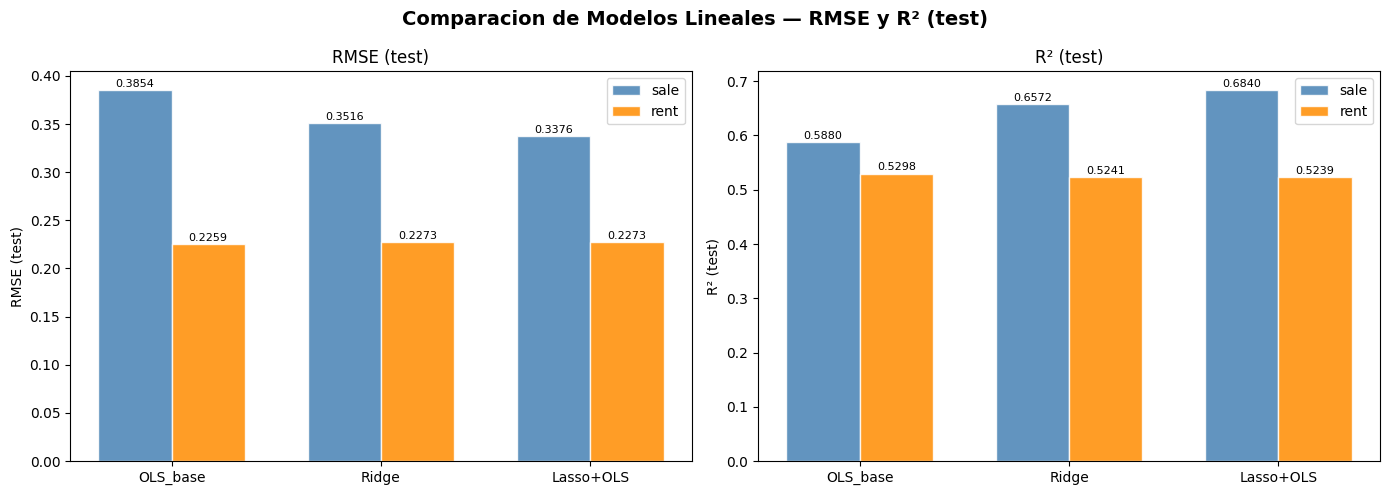

In [14]:
modelos      = ["OLS_base", "Ridge", "Lasso+OLS"]
datasets_lst = ["sale", "rent"]
colors       = {"sale": "steelblue", "rent": "darkorange"}
x            = np.arange(len(modelos))
width        = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Comparacion de Modelos Lineales — RMSE y R² (test)",
    fontsize=14, fontweight="bold"
)

for ax, metric, ylabel in zip(
    axes,
    ["test_RMSE", "test_R2"],
    ["RMSE (test)", "R² (test)"],
):
    for i, ds in enumerate(datasets_lst):
        subset = (
            results_df[results_df["dataset"] == ds]
            .set_index("modelo")
            .reindex(modelos)
        )
        offset = (i - 0.5) * width
        bars = ax.bar(
            x + offset, subset[metric], width,
            label=ds, color=colors[ds], alpha=0.85, edgecolor="white"
        )
        # Etiquetas encima de cada barra
        for bar, val in zip(bars, subset[metric]):
            if pd.notna(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.001 if metric == "test_RMSE" else 0.002),
                    f"{val:.4f}",
                    ha="center", va="bottom", fontsize=8
                )
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, fontsize=10)
    ax.set_title(ylabel, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()

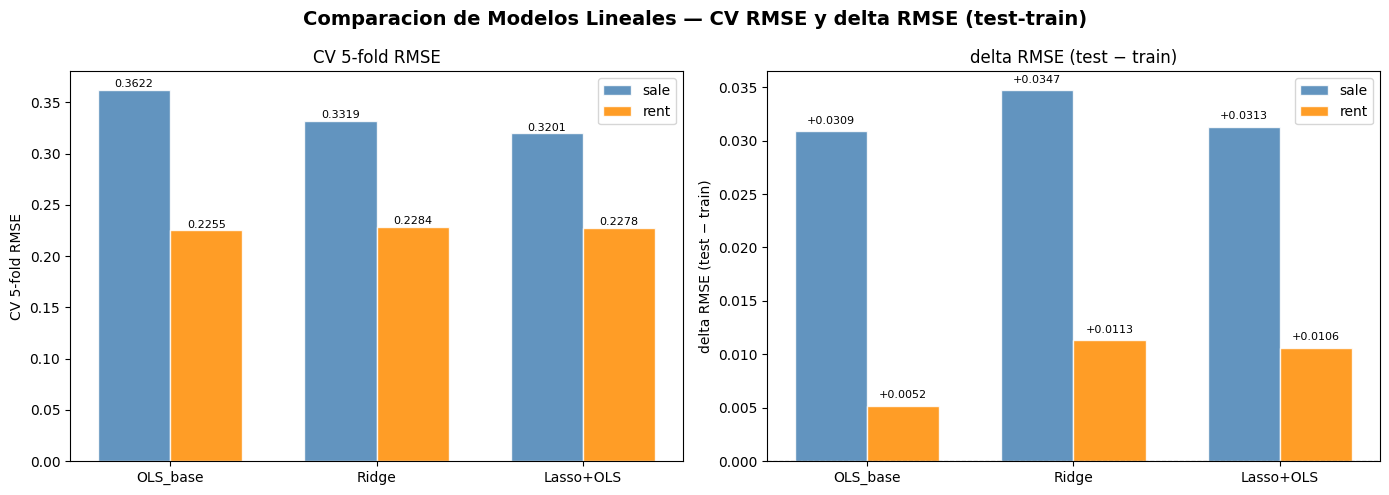

In [15]:
# Grafico adicional: CV RMSE y delta_RMSE (overfitting)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Comparacion de Modelos Lineales — CV RMSE y delta RMSE (test-train)",
    fontsize=14, fontweight="bold"
)

cv_rmse_col = f"CV_{N_SPLITS}f_RMSE"

for ax, metric, ylabel in zip(
    axes,
    [cv_rmse_col, "delta_RMSE"],
    [f"CV {N_SPLITS}-fold RMSE", "delta RMSE (test − train)"],
):
    for i, ds in enumerate(datasets_lst):
        subset = (
            results_df[results_df["dataset"] == ds]
            .set_index("modelo")
            .reindex(modelos)
        )
        offset = (i - 0.5) * width
        vals   = subset[metric]
        bar_colors = [colors[ds]] * len(vals)
        bars = ax.bar(
            x + offset, vals, width,
            label=ds, color=colors[ds], alpha=0.85, edgecolor="white"
        )
        for bar, val in zip(bars, vals):
            if pd.notna(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.0005 if val >= 0 else -0.003),
                    f"{val:+.4f}" if metric == "delta_RMSE" else f"{val:.4f}",
                    ha="center", va="bottom", fontsize=8
                )
    if metric == "delta_RMSE":
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, fontsize=10)
    ax.set_title(ylabel, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()

---
## Modelo Definitivo — Ridge con selección Lasso

La sección de exploración (OLS base, Ridge, Lasso+OLS) revela qué features aportan señal.
Aquí se consolida el modelo definitivo exportable al híbrido (NB54):

1. Se usa `LassoCV` sobre el conjunto candidato más amplio para seleccionar features
2. Se entrena `RidgeCV` sobre las features seleccionadas para encontrar el alpha óptimo
3. Se exponen `RIDGE_FEATURES_DEF` y `RIDGE_ALPHA_DEF` por dataset


MODELO DEFINITIVO RIDGE — SALE

Features seleccionadas por LassoCV (49):
  ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'latitud_2', 'longitud_2', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'superficie_construida_m2_2', 'numero_banos_2', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Guarnizo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Mogro', 'municipio_Noja', 'municipio_Ortuella', 'municipio_Piélagos', 'municipio_Ribamontan al 

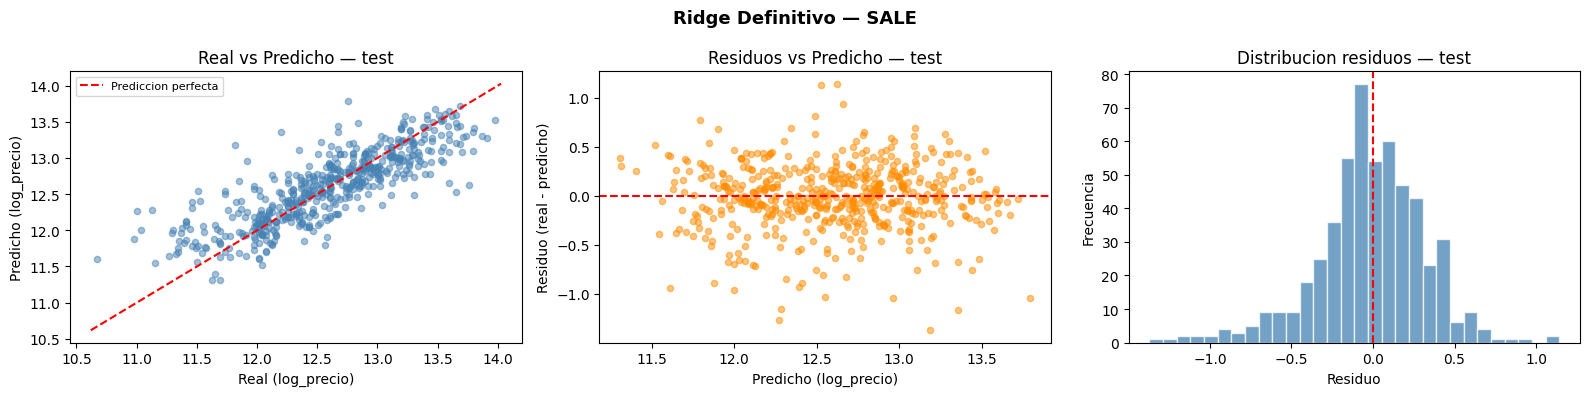


MODELO DEFINITIVO RIDGE — RENT

Features seleccionadas por LassoCV (22):
  ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'distancia_min_playa_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_banos_superficie', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'numero_dormitorios_2', 'municipio_El Astillero', 'municipio_Laredo', 'municipio_Piélagos', 'municipio_Santa Cruz de Bezana', 'municipio_Santander', 'municipio_Suances', 'municipio_Torrelavega', 'municipio_otro']
Descartadas (15): ['latitud', 'longitud', 'obra_nueva', 'distancia_min_supermercado_km', 'interaccion_superficie_banos', 'interaccion_planta_sin_ascensor_piso', 'latitud_2', 'longitud_2', 'interaccion_latitud_longitud', 'superficie_construida_m2_2', 'numero_banos_2', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Camargo', 'municipio_Castro-Urdiales']

Alpha óptimo (Ridge

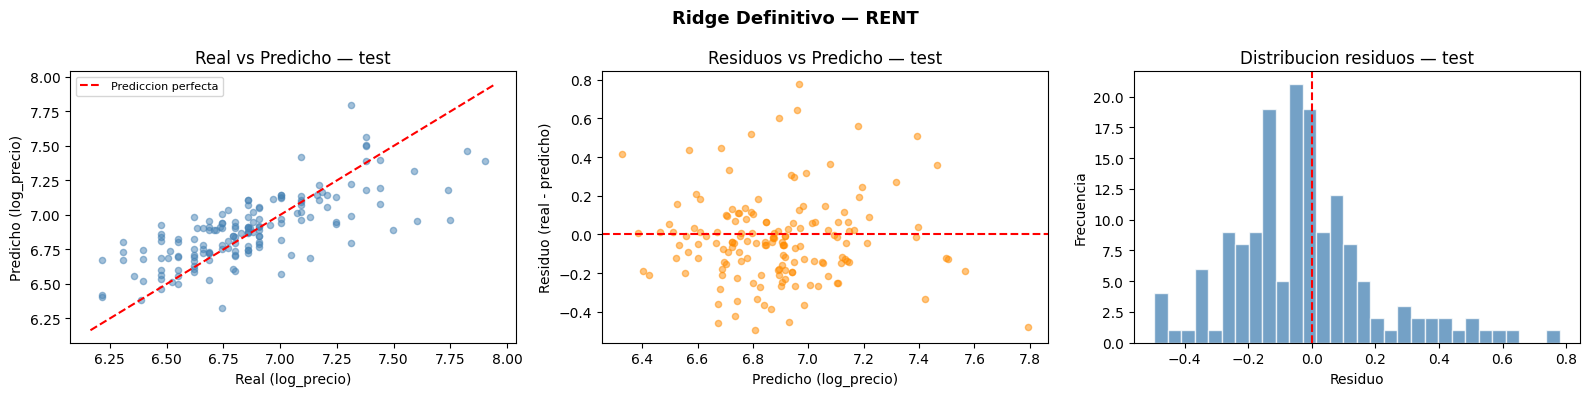


RESUMEN PARA NB54 — copiar en RIDGE_FEATURES y RIDGE_ALPHA:

  # SALE
  RIDGE_FEATURES_DEF['sale'] = ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'latitud_2', 'longitud_2', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'superficie_construida_m2_2', 'numero_banos_2', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Guarnizo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Mogro', 'municipio_Noja', 'municipio_Ortuella', 'municipio_Piélagos',

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELO DEFINITIVO — Ridge con selección de variables por LassoCV
# ══════════════════════════════════════════════════════════════════════════════
# Variables exportadas al híbrido (NB54):
#   RIDGE_FEATURES_DEF  — features seleccionadas por Lasso (por dataset)
#   RIDGE_ALPHA_DEF     — alpha óptimo de RidgeCV (por dataset)

RIDGE_FEATURES_DEF = {}
RIDGE_ALPHA_DEF    = {}

for dataset_name, dataset_path in DATASETS.items():
    print(f"\n{'='*80}")
    print(f"MODELO DEFINITIVO RIDGE — {dataset_name.upper()}")
    print(f"{'='*80}")

    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    y  = df[TARGET_COL].copy()

    # Partir del conjunto Lasso (el más amplio de features candidatas)
    X_lasso = build_candidate_X(df, CANDIDATE_FEATURES_LASSO)
    X_train_l, X_test_l, y_train, y_test = train_test_split(
        X_lasso, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    # Selección de variables con LassoCV
    selected_feats, alpha_lasso, lasso_coefs = select_features_lasso(X_train_l, y_train)
    print(f"\nFeatures seleccionadas por LassoCV ({len(selected_feats)}):")
    print(f"  {selected_feats}")
    dropped = [f for f in X_lasso.columns if f not in selected_feats]
    print(f"Descartadas ({len(dropped)}): {dropped}")

    if not selected_feats:
        selected_feats = X_lasso.columns.tolist()
        print("  Lasso no eliminó ninguna feature — se usan todas.")

    # Entrenar Ridge definitivo sobre features seleccionadas
    X_train_d  = X_train_l[selected_feats]
    X_test_d   = X_test_l[selected_feats]
    X_def      = X_lasso[selected_feats]
    n_feat     = len(selected_feats)

    scaler_d   = StandardScaler()
    X_train_ds = scaler_d.fit_transform(X_train_d)
    X_test_ds  = scaler_d.transform(X_test_d)

    ridge_def = RidgeCV(alphas=RIDGE_ALPHAS, cv=N_SPLITS, scoring="neg_mean_squared_error")
    ridge_def.fit(X_train_ds, y_train)
    alpha_opt = ridge_def.alpha_

    pred_train = ridge_def.predict(X_train_ds)
    pred_test  = ridge_def.predict(X_test_ds)

    train_m = compute_metrics(y_train, pred_train, n_feat)
    test_m  = compute_metrics(y_test,  pred_test,  n_feat)
    cv_m    = cv_ridge_metrics(X_def, y, alpha_opt, n_feat)

    print(f"\nAlpha óptimo (RidgeCV): {alpha_opt:.6f}")
    print(pd.DataFrame([
        {"split": "train",                **train_m},
        {"split": f"CV ({N_SPLITS}-fold)", **cv_m},
        {"split": "test",                 **test_m},
    ]).round(5).to_string(index=False))
    print(f"\n  delta RMSE test-train : {test_m['RMSE'] - train_m['RMSE']:+.5f}")
    print(f"  delta R2   train-test : {train_m['R2'] - test_m['R2']:+.5f}")
    print(f"  R2 ajustado (test)    : {test_m['R2_ajustado']:.5f}")

    # Coeficientes estandarizados
    coef_df = pd.DataFrame({"feature": X_train_d.columns, "coef_std": ridge_def.coef_})
    coef_df["|coef_std|"] = coef_df["coef_std"].abs()
    coef_df = coef_df.sort_values("|coef_std|", ascending=False).drop(columns="|coef_std|")
    print(f"\n  Top 15 coeficientes estandarizados:")
    print(coef_df.head(15).round(5).to_string(index=False))

    plot_diagnostics(y_test, pred_test, f"Ridge Definitivo — {dataset_name.upper()}")

    RIDGE_FEATURES_DEF[dataset_name] = selected_feats
    RIDGE_ALPHA_DEF[dataset_name]    = float(alpha_opt)

print("\n" + "="*80)
print("RESUMEN PARA NB54 — copiar en RIDGE_FEATURES y RIDGE_ALPHA:")
print("="*80)
for ds in RIDGE_FEATURES_DEF:
    print(f"\n  # {ds.upper()}")
    print(f"  RIDGE_FEATURES_DEF[\'{ds}\'] = {RIDGE_FEATURES_DEF[ds]}")
    print(f"  RIDGE_ALPHA_DEF[\'{ds}\']    = {RIDGE_ALPHA_DEF[ds]:.6f}")